In [1]:
#from langchain_anthropic import ChatAnthropic
from langchain_openai import ChatOpenAI
import os
from load_dotenv import load_dotenv

load_dotenv() #This function will load everything which is saved in our .env file and will make them available
              # in the os.environ dictionary (env variables)

if os.environ.get("OPENAI_API_KEY"):
    print("Bro, API KEY Variable Exists")
else: 
    raise ValueError("OPENAI_API_KEY not found")

from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

llm_openai = ChatOpenAI(model ='gpt-5-mini', temperature=0)

Bro, API KEY Variable Exists


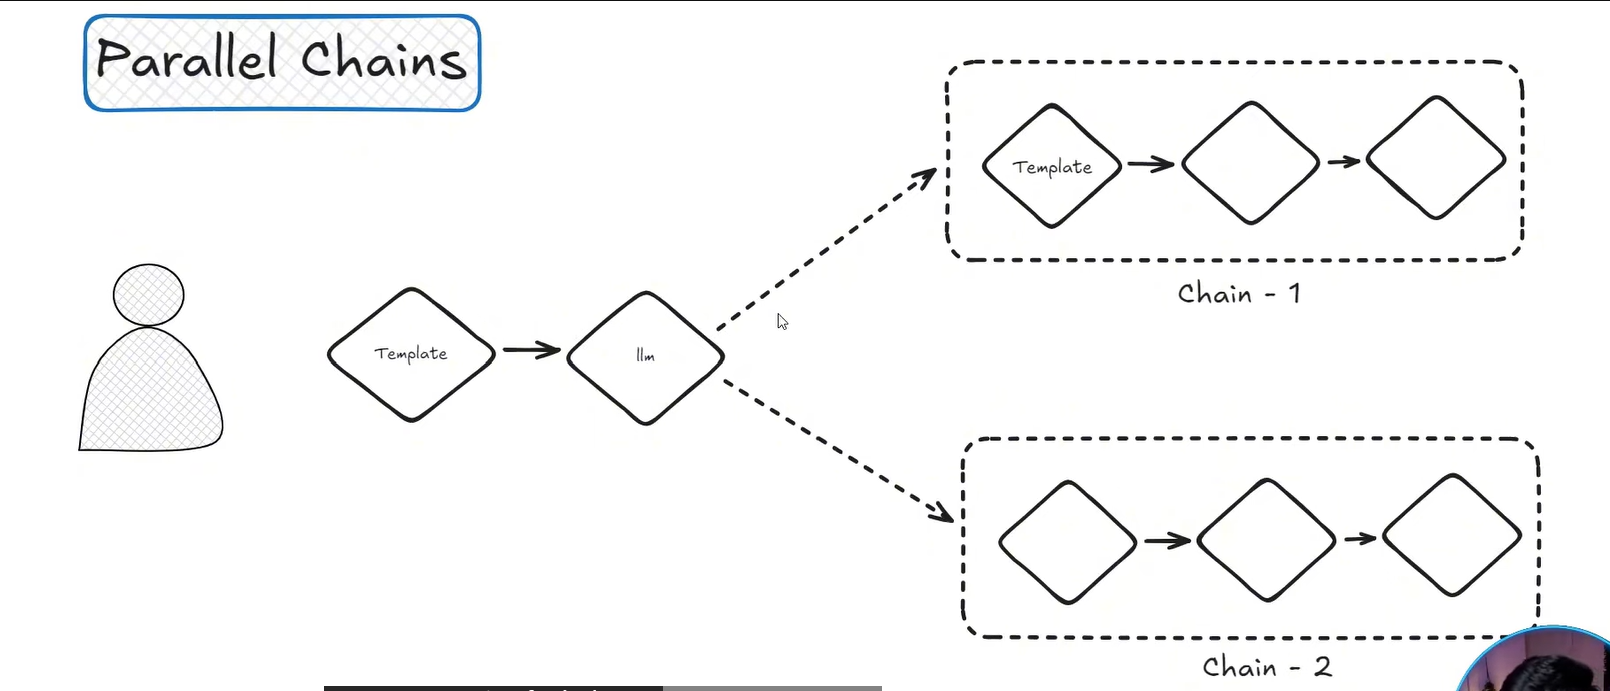

# **CHAIN WITH Parallel Chains**

In [2]:
# TASK1 - Prompt

prompt_template = ChatPromptTemplate.from_messages([
    ("system", "You are a movie summarizer"),
    ("human", "Please summarize the movie in brief : {input}")
])

In [ ]:
# TASK2 - LLM

llm_openai = ChatOpenAI(model ='gpt-5-mini', temperature=0)

In [4]:
# TASK3 - Str Parser

str_parser = StrOutputParser()

In [ ]:
# TASK4 - Custom Runnable
from langchain_core.runnables import RunnableLambda

def dictionary_maker(text:str) -> dict:

    return {"text": text}

dictionary_maker_runnable = RunnableLambda(dictionary_maker)  # Wraps function into runnable (so it can be part of chain)

Why we convert the ouput -> Dictionary, because next chains expect input like: {"text": "summary here"}

# **Parallel Chain 1**

In [8]:
# Task1- Prompt

linkedin_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a LinkedIn post generator"),
    ("human", "Create a post for the following text for LinkedIn: {text}")
])

# Task2 - LLM

llm_openai = ChatOpenAI(model ='gpt-5-mini', temperature=0)

# Task3 - Str Parser

str_parser = StrOutputParser()  

chain_linkedin = linkedin_prompt | llm_openai | str_parser

Now we need to create one custome which can create our  LLM string output to dictionary. Why?

Because in our next task, input should be in key-value pair. We already created that function above our Parallel Chain 1, which should be useful for both of our Chain.

# **Parallel Chain 2**

here we will define chain in 2nd way by creating a function. above in chain 1 we have done seperately.

In [12]:
from langchain_core.runnables import RunnableParallel, RunnableLambda

In [ ]:
def insta_chain(text:dict):

    text = text["text"]  # Extract actual text

    insta_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a Instagram post generator"),
    ("human", "Create a post for the following text for Instagram: {text}")])

    # Task2 - LLM
    llm_openai = ChatOpenAI(model ='gpt-5-mini', temperature=0)

    # Task3 - Str Parser
    str_parser = StrOutputParser()  

    chain_insta = insta_prompt | llm_openai | str_parser

    result = chain_insta.invoke(text)

    return result

insta_chain_runnable = RunnableLambda(insta_chain)  #creating a lambda function for it.

So we can see that we can define everything in the function. because whenever we create function we have more control. Why?

because we know the ouput of insta_prompt will go inside our task2 [LLM].

If I need to make any changes I can do it in the function itself. I don't need to depend on like this will generate the ouput like this (means wrong). I am open to do anything.

Now we need to finalize the Final Orchestration. Than means we need to now arrange all the tasks and our parallel tasks as well.


## **Final Orchestration**

In [13]:
final_chain = (
    prompt_template |
    llm_openai |
    str_parser |
    dictionary_maker_runnable |
    RunnableParallel(branches = {"linkedin": chain_linkedin, "instagram": insta_chain_runnable})
)

In [14]:
final_chain.invoke("KGF")

{'branches': {'linkedin': 'Just finished rewatching KGF: Chapter 1 — a raw, high-energy story about ambition, power and the cost of both.\n\nSet in the brutal Kolar Gold Fields, the film follows Rocky (Yash), a slum-born outsider driven by a promise to his dying mother: to become rich and powerful. Recruited into the underworld and sent to seize control of the lawless mines, Rocky uses charisma, violence and strategy to win influence among the oppressed workers and challenge the entrenched criminal hierarchy. Visually stylized and relentlessly paced, the movie blends action with themes of class struggle, destiny and leadership — and closes on a cliffhanger that demands a second chapter.\n\nWhat resonates beyond the spectacle is the human story underneath: ambition without a moral compass invites conflict; leadership can emerge from the margins; and storytelling can turn gritty reality into a compelling lesson on power dynamics.\n\nCurious to hear others’ takes — which elements of KGF s

Now let's say we want to display our output in a better way.

# **Chain as a Runnable**

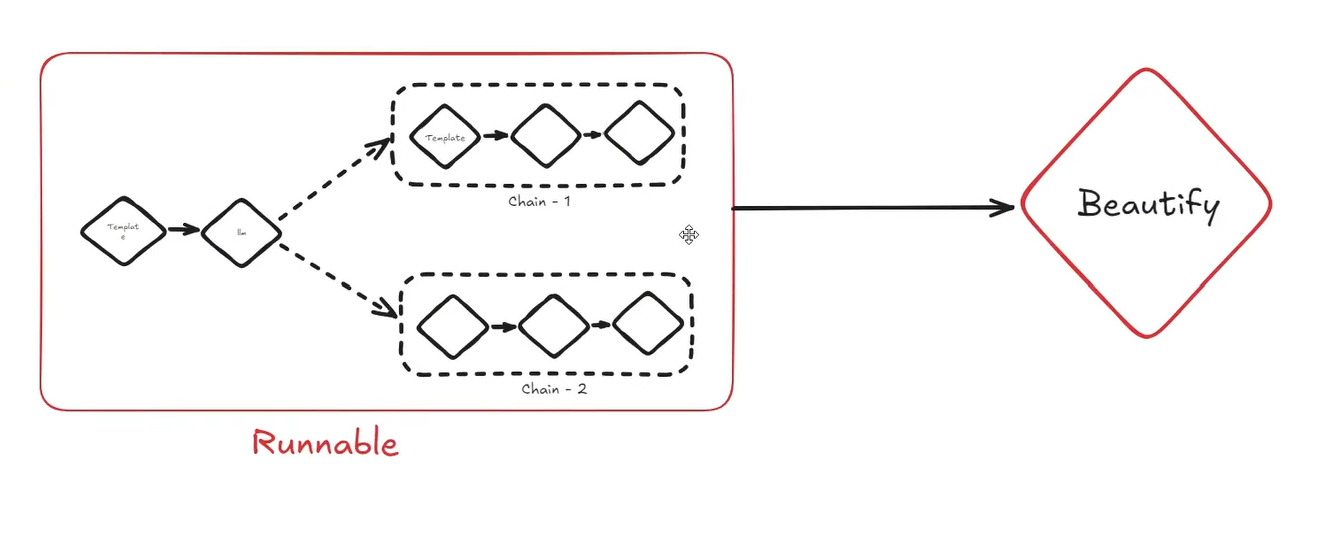

Let's say once we have the above chain, final chain now we want to extend that chain, and we want to connect one more function and what this new function returns, it will beautifies the output.

In [17]:
# Task1 - Beautify Function

def beautify(final_response:dict)-> dict:

    linkedin_response = final_response['branches']['linkedin']
    instagram_response = final_response['branches']["instagram"]

    return {"linkedin": linkedin_response, "instagram": instagram_response}

beautify_runnable = RunnableLambda(beautify)

# Task2 - Final Chain

# final_chain

# Beautified chain
beautified_chain = final_chain | beautify_runnable

above we can literally use the entire chain as my runnable. It is a bydefault behavior. 

Yes, we need to explicitly convert our python function as runnable. If we are creating a chain, we don't need to convert into runnable. That is runnable by default.

In [18]:
beautified_chain.invoke("Pushpa")

{'linkedin': 'Just watched Pushpa: The Rise — a raw, gritty Telugu action-drama that centers on ambition, power and survival.\n\nPushpa Raj (Allu Arjun) starts as a lowly laborer in the Seshachalam forests and climbs the ranks of a red sandalwood smuggling network through cunning, brutality and sheer ambition. Along the way he falls for Srivalli (Rashmika Mandanna) and increasingly collides with corrupt officials, rival smugglers and a determined police officer (Fahadh Faasil). The film traces loyalty, betrayal and a ruthless ascent, finishing on a tense cliffhanger that sets up the sequel. Standouts: earthy tone, raw performances and high-impact action set pieces.\n\nWhy it matters beyond cinema: it’s a vivid case study in how ambition and networks create opportunity — and how ethical compromise and power struggles shape outcomes. Great storytelling, but also a reminder that leadership without accountability has costs.\n\nSeen it yet? What lessons or impressions did you take away?\n#P